# Lab 2 - Support Vector Regression (SVR)


## Step 1 - Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Step 2 - Load Dataset

In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/Foto/Posisi_gaji.csv')
print(dataset)
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values

              Posisi  Level     Gaji
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


## Step 3 - Feature Scaling


In [4]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y.reshape(-1, 1))

## Step 4 - Fitting the SVR Model

In [5]:
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X, y.ravel())

SVR()

## Step 5 - Visualising SVR Results

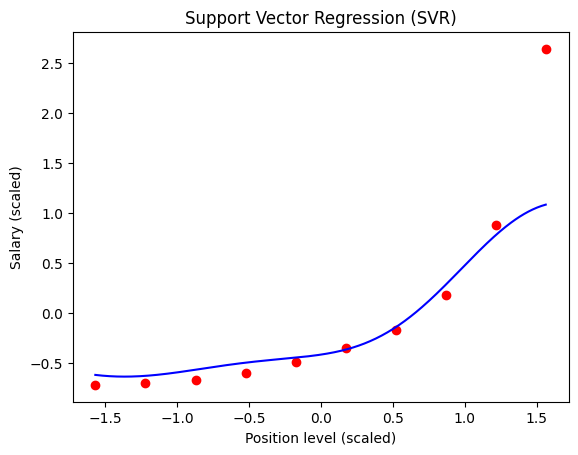

In [6]:
X_grid = np.arange(X.min(), X.max(), 0.01).reshape(-1, 1)
plt.scatter(X, y, color='red')
plt.plot(X_grid, regressor.predict(X_grid), color='blue')
plt.title('Support Vector Regression (SVR)')
plt.xlabel('Position level (scaled)')
plt.ylabel('Salary (scaled)')
plt.show()

## Step 6 - Predicting Results


In [7]:
position_level_pred = np.array([[6.5]])
position_level_pred = sc_X.transform(position_level_pred)
salary_pred = regressor.predict(position_level_pred)
salary_pred = sc_y.inverse_transform(salary_pred.reshape(-1, 1))

## Step 7 - Displaying Results

In [8]:
print('Predicted Salary for Position Level 6.5:', salary_pred[0])

Predicted Salary for Position Level 6.5: [170370.0204065]


**Result validation.** With the standard Position_Salaries data the module reports about 170370.02. The blue curve follows the non-linear relation between level and salary, and the red dots are the observed data.

## Step 8 - Evaluating the SVR Model

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_actual = y
y_pred = regressor.predict(X)

mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R-squared:', r2)

MAE: 0.22299274095734414
MSE: 0.24839989293792014
RMSE: 0.4983973243687411
R-squared: 0.7516001070620798


In [10]:
y_true_orig = sc_y.inverse_transform(y_actual)
y_pred_orig = sc_y.inverse_transform(y_pred.reshape(-1, 1))
print('MAE (salary units):', mean_absolute_error(y_true_orig, y_pred_orig))
print('RMSE (salary units):', np.sqrt(mean_squared_error(y_true_orig, y_pred_orig)))

MAE (salary units): 63332.39208968966
RMSE (salary units): 141550.32413997417
